In [1]:
from pathlib import Path
import os, getpass, pickle, hashlib, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tabpfn_client import TabPFNClassifier
from importlib.metadata import version

RESULTS_DIR = Path("decision_probe_results")
with (RESULTS_DIR / "demo_state.pkl").open("rb") as file:
    state = pickle.load(file)
globals().update(state)

if not os.environ.get("TABPFN_TOKEN"):
    os.environ["TABPFN_TOKEN"] = getpass.getpass("Prior Labs API key: ").strip()
assert os.environ.get("TABPFN_TOKEN"), "API key required."

print(f"Loaded {len(probe_results):,} edits across {len(summary)} high-risk records.")

Loaded 1,485 edits across 45 high-risk records.


In [2]:
candidate_meta = probe_results[["record_id", "feature", "old_value", "new_value", "relative_reduction"]].reset_index(drop=True).copy()
candidate_meta.index.name = "candidate_id"
candidate_X = X_test.loc[candidate_meta.record_id.to_numpy()].reset_index(drop=True).copy()

for feature in FEATURES:
    positions = np.flatnonzero(candidate_meta.feature.eq(feature).to_numpy())
    candidate_X.loc[positions, feature] = candidate_meta.loc[positions, "new_value"].to_numpy()

candidate_X = candidate_X.astype(X_test.dtypes.to_dict())
original_ids = summary.index.tolist()
original_X = X_test.loc[original_ids].copy()
original_positions = {rid: pos for pos, rid in enumerate(original_ids)}
candidate_original_positions = candidate_meta.record_id.map(original_positions).to_numpy()

assert candidate_X.shape == (len(candidate_meta), X_test.shape[1])
for feature in X_test.columns:
    unchanged = candidate_meta.feature.ne(feature).to_numpy()
    expected = X_test.loc[candidate_meta.record_id.to_numpy(), feature].reset_index(drop=True)
    assert candidate_X.loc[unchanged, feature].reset_index(drop=True).equals(expected.loc[unchanged].reset_index(drop=True))

print(f"Verified {len(candidate_X):,} candidates: exactly one specified feature edit per row.")

Verified 1,485 candidates: exactly one specified feature edit per row.


In [3]:
SEARCH_REPEATS, SEARCH_TRAIN_FRACTION, SEARCH_BATCH_SIZE = 10, 0.80, 250
config = {
    "repeats": SEARCH_REPEATS, "train_fraction": SEARCH_TRAIN_FRACTION,
    "batch_size": SEARCH_BATCH_SIZE, "seed": SEED, "model_selection": "automatic_default",
    "model_random_state": 0, "client_version": version("tabpfn-client")
}
fingerprint = hashlib.sha256(json.dumps(config, sort_keys=True).encode())
for obj in [X_train, y_train, original_X, candidate_meta, candidate_X]:
    fingerprint.update(pd.util.hash_pandas_object(obj, index=True).values.tobytes())
RUN_DIR = RESULTS_DIR / f"stable_search_{fingerprint.hexdigest()[:12]}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

for repeat in range(SEARCH_REPEATS):
    checkpoint = RUN_DIR / f"repeat_{repeat:02d}.pkl"
    if checkpoint.exists():
        print(f"Repeat {repeat + 1}/{SEARCH_REPEATS}: already saved.")
        continue
    sub_X, _, sub_y, _ = train_test_split(
        X_train, y_train, train_size=SEARCH_TRAIN_FRACTION, stratify=y_train,
        random_state=SEED + 100 + repeat
    )
    search_model = TabPFNClassifier(random_state=0)
    search_model.fit(sub_X, sub_y)
    class_idx = list(search_model.classes_).index(1)
    original_p = np.asarray(search_model.predict_proba(original_X))[:, class_idx]
    candidate_p = []
    for start in range(0, len(candidate_X), SEARCH_BATCH_SIZE):
        batch = candidate_X.iloc[start:start + SEARCH_BATCH_SIZE]
        candidate_p.extend(np.asarray(search_model.predict_proba(batch))[:, class_idx])
        print(f"Repeat {repeat + 1}: {min(start + SEARCH_BATCH_SIZE, len(candidate_X))}/{len(candidate_X)} edits")
    candidate_p = np.asarray(candidate_p)
    assert np.isfinite(original_p).all() and np.isfinite(candidate_p).all()
    payload = {"repeat": repeat + 1, "original_p": original_p, "candidate_p": candidate_p}
    temporary = checkpoint.with_suffix(".tmp")
    with temporary.open("wb") as file:
        pickle.dump(payload, file, protocol=pickle.HIGHEST_PROTOCOL)
    temporary.replace(checkpoint)

print("All candidate stability runs saved:", RUN_DIR.resolve())

Repeat 1: 250/1485 edits
Repeat 1: 500/1485 edits
Repeat 1: 750/1485 edits
Repeat 1: 1000/1485 edits
Repeat 1: 1250/1485 edits
Repeat 1: 1485/1485 edits
Repeat 2: 250/1485 edits
Repeat 2: 500/1485 edits
Repeat 2: 750/1485 edits
Repeat 2: 1000/1485 edits
Repeat 2: 1250/1485 edits
Repeat 2: 1485/1485 edits
Repeat 3: 250/1485 edits
Repeat 3: 500/1485 edits
Repeat 3: 750/1485 edits
Repeat 3: 1000/1485 edits
Repeat 3: 1250/1485 edits
Repeat 3: 1485/1485 edits
Repeat 4: 250/1485 edits
Repeat 4: 500/1485 edits
Repeat 4: 750/1485 edits
Repeat 4: 1000/1485 edits
Repeat 4: 1250/1485 edits
Repeat 4: 1485/1485 edits
Repeat 5: 250/1485 edits
Repeat 5: 500/1485 edits
Repeat 5: 750/1485 edits
Repeat 5: 1000/1485 edits
Repeat 5: 1250/1485 edits
Repeat 5: 1485/1485 edits
Repeat 6: 250/1485 edits
Repeat 6: 500/1485 edits
Repeat 6: 750/1485 edits
Repeat 6: 1000/1485 edits
Repeat 6: 1250/1485 edits
Repeat 6: 1485/1485 edits
Repeat 7: 250/1485 edits
Repeat 7: 500/1485 edits
Repeat 7: 750/1485 edits
Repeat 

In [4]:
runs = []
for repeat in range(SEARCH_REPEATS):
    with (RUN_DIR / f"repeat_{repeat:02d}.pkl").open("rb") as file:
        runs.append(pickle.load(file))

original_matrix = np.vstack([run["original_p"] for run in runs])
candidate_matrix = np.vstack([run["candidate_p"] for run in runs])
before_matrix = original_matrix[:, candidate_original_positions]
before_high = before_matrix >= THRESHOLD
after_low = candidate_matrix < THRESHOLD
paired_flip = before_high & after_low
MARGIN = 0.02
margin_flip = (before_matrix >= THRESHOLD + MARGIN) & (candidate_matrix <= THRESHOLD - MARGIN)

stable_candidates = candidate_meta.copy()
stable_candidates["original_high_risk_rate"] = before_high.mean(axis=0)
stable_candidates["modified_low_risk_rate"] = after_low.mean(axis=0)
stable_candidates["paired_flip_rate"] = paired_flip.mean(axis=0)
stable_candidates["margin_flip_rate"] = margin_flip.mean(axis=0)
stable_candidates["mean_original_p"] = before_matrix.mean(axis=0)
stable_candidates["mean_modified_p"] = candidate_matrix.mean(axis=0)
stable_candidates["mean_delta_p"] = (candidate_matrix - before_matrix).mean(axis=0)
stable_candidates.to_csv(RUN_DIR / "candidate_stability.csv")
display(stable_candidates.sort_values(["paired_flip_rate", "relative_reduction"], ascending=[False, True]).head(15))

,record_id,feature,old_value,new_value,relative_reduction,original_high_risk_rate,modified_low_risk_rate,paired_flip_rate,margin_flip_rate,mean_original_p,mean_modified_p,mean_delta_p
candidate_id,,,,,,,,,,,,
462,840,duration,36.0,22.0,0.388889,1.0,1.0,1.0,0.6,0.585106,0.453887,-0.131219
458,840,duration,36.0,16.0,0.555556,1.0,1.0,1.0,0.8,0.585106,0.446674,-0.138432
457,840,duration,36.0,15.0,0.583333,1.0,1.0,1.0,1.0,0.585106,0.411153,-0.173952
456,840,duration,36.0,14.0,0.611111,1.0,1.0,1.0,1.0,0.585106,0.407840,-0.177266
455,840,duration,36.0,13.0,0.638889,1.0,1.0,1.0,1.0,0.585106,0.399653,-0.185453
498,431,credit_amount,11328.0,3965.0,0.649982,1.0,1.0,1.0,0.8,0.594089,0.439896,-0.154193
454,840,duration,36.0,12.0,0.666667,1.0,1.0,1.0,0.9,0.585106,0.416221,-0.168884
453,840,duration,36.0,11.0,0.694444,1.0,1.0,1.0,1.0,0.585106,0.369789,-0.215317
497,431,credit_amount,11328.0,3398.0,0.700035,1.0,1.0,1.0,0.8,0.594089,0.431329,-0.162761


In [5]:
def select_stable_edits(required_rate=0.80, require_margin=False):
    assert 0 < required_rate <= 1
    metric = "margin_flip_rate" if require_margin else "paired_flip_rate"
    eligible = stable_candidates.loc[stable_candidates[metric] >= required_rate]
    selected = eligible.sort_values(
        ["relative_reduction", metric, "mean_modified_p", "feature"],
        ascending=[True, False, True, True]
    ).drop_duplicates("record_id").set_index("record_id")
    report = baseline.loc[original_ids, ["p_bad"]].rename(columns={"p_bad": "original_full_train_p"})
    report = report.join(selected)
    report["qualifying_edit_found"] = report.feature.notna()
    return report

stable_report = select_stable_edits(required_rate=0.80)
print(f"Records with an edit retaining paired flips in ≥8/10 subsets: {stable_report.qualifying_edit_found.sum()}/{len(stable_report)}")
display(stable_report.sort_values(["qualifying_edit_found", "relative_reduction"], ascending=[False, True]).head(15))

coverage = []
for rate in [0.50, 0.70, 0.80, 0.90, 1.00]:
    report = select_stable_edits(rate)
    coverage.append({
        "required_observed_stability": rate,
        "records_with_qualifying_edit": int(report.qualifying_edit_found.sum()),
        "median_relative_reduction": report.loc[report.qualifying_edit_found, "relative_reduction"].median()
    })
display(pd.DataFrame(coverage))

Records with an edit retaining paired flips in ≥8/10 subsets: 19/45


,original_full_train_p,feature,old_value,new_value,relative_reduction,original_high_risk_rate,modified_low_risk_rate,paired_flip_rate,margin_flip_rate,mean_original_p,mean_modified_p,mean_delta_p,qualifying_edit_found
1,0.543003,duration,48.0,33.0,0.312500,0.8,1.0,0.8,0.7,0.529587,0.411319,-0.118267,True
840,0.620175,duration,36.0,22.0,0.388889,1.0,1.0,1.0,0.6,0.585106,0.453887,-0.131219,True
431,0.646097,credit_amount,11328.0,6230.0,0.450035,1.0,0.8,0.8,0.6,0.594089,0.469100,-0.124990,True
182,0.581650,duration,21.0,11.0,0.476190,0.8,1.0,0.8,0.5,0.540846,0.412302,-0.128544,True
677,0.568439,duration,72.0,33.0,0.541667,0.8,1.0,0.8,0.7,0.569848,0.390501,-0.179347,True
658,0.557353,duration,30.0,11.0,0.633333,0.9,1.0,0.9,0.5,0.541511,0.421956,-0.119555,True
289,0.686914,duration,24.0,8.0,0.666667,1.0,0.8,0.8,0.8,0.637184,0.425398,-0.211786,True
678,0.639036,duration,24.0,8.0,0.666667,1.0,0.8,0.8,0.7,0.657101,0.430768,-0.226333,True
235,0.655599,duration,24.0,8.0,0.666667,1.0,0.8,0.8,0.7,0.635601,0.443134,-0.192467,True
548,0.599571,duration,12.0,4.0,0.666667,1.0,0.8,0.8,0.8,0.597807,0.435463,-0.162344,True


,required_observed_stability,records_with_qualifying_edit,median_relative_reduction
0,0.5,30,0.444444
1,0.7,25,0.600000
2,0.8,19,0.666667
3,0.9,11,0.708333
4,1.0,7,0.777778


In [6]:
expanded_state = {
    "stable_candidates": stable_candidates, "original_matrix": original_matrix,
    "candidate_matrix": candidate_matrix, "original_ids": original_ids,
    "SEARCH_REPEATS": SEARCH_REPEATS, "THRESHOLD": THRESHOLD, "MARGIN": MARGIN,
    "config": config, "baseline": baseline, "best_flips": best_flips,
    "probe_results": probe_results
}
with (RUN_DIR / "search_state.pkl").open("wb") as file:
    pickle.dump(expanded_state, file, protocol=pickle.HIGHEST_PROTOCOL)
print("Expanded search saved:", (RUN_DIR / "search_state.pkl").resolve())

Expanded search saved: /homes/mxqasim/Hackathon/decision_probe_results/stable_search_412b57d59795/search_state.pkl


In [7]:
%pip install -q ipywidgets


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, HTML

record_control = widgets.Dropdown(
    options=[(f"Record {rid}", rid) for rid in original_ids],
    value=431 if 431 in original_ids else original_ids[0], description="Record:"
)
stability_control = widgets.IntSlider(value=8, min=1, max=SEARCH_REPEATS, description="Min flips:", continuous_update=False)
cost_control = widgets.IntSlider(value=100, min=5, max=100, step=5, description="Max change %:", continuous_update=False)
feature_control = widgets.Dropdown(options=["Either", "credit_amount", "duration"], description="Feature:")
margin_control = widgets.Checkbox(value=False, description="Require 2-point margin on both sides")
dashboard_output = widgets.Output()

def render_search(change=None):
    with dashboard_output:
        clear_output(wait=True)
        rid = record_control.value
        metric = "margin_flip_rate" if margin_control.value else "paired_flip_rate"
        required = stability_control.value / SEARCH_REPEATS
        all_edits = stable_candidates.loc[stable_candidates.record_id == rid].copy()
        allowed = all_edits.loc[all_edits.relative_reduction <= cost_control.value / 100 + 1e-9]
        if feature_control.value != "Either":
            allowed = allowed.loc[allowed.feature == feature_control.value]
        eligible = allowed.loc[allowed[metric] >= required]
        eligible = eligible.sort_values(
            ["relative_reduction", metric, "mean_modified_p", "feature"],
            ascending=[True, False, True, True]
        )
        chosen = eligible.iloc[0] if not eligible.empty else None

        display(HTML(f"<h3>Record {rid} · Original full-training risk: {baseline.at[rid, 'p_bad']:.1%}</h3>"))
        print(f"Requirement: ≥{stability_control.value}/{SEARCH_REPEATS} paired flips | "
              f"Maximum relative reduction: {cost_control.value}%")
        if chosen is None:
            print("No tested edit meets these requirements. Adjust the controls to explore alternatives.")
        else:
            print(f"Smallest qualifying edit: {chosen.feature} {chosen.old_value:g} → {chosen.new_value:g}")
            print(f"Relative reduction: {chosen.relative_reduction:.1%}")
            print(f"Paired flips: {round(chosen.paired_flip_rate * SEARCH_REPEATS)}/{SEARCH_REPEATS} | "
                  f"Margin-qualified flips: {round(chosen.margin_flip_rate * SEARCH_REPEATS)}/{SEARCH_REPEATS}")
            print(f"Mean original risk: {chosen.mean_original_p:.1%} | Mean modified risk: {chosen.mean_modified_p:.1%}")

        if rid in best_flips.index:
            original_edit = best_flips.loc[rid]
            match = all_edits.loc[
                all_edits.feature.eq(original_edit.feature) &
                np.isclose(all_edits.new_value, original_edit.new_value)
            ]
            if not match.empty:
                previous = match.iloc[0]
                print(f"Original single-run choice: {previous.feature} → {previous.new_value:g}, "
                      f"{previous.relative_reduction:.1%} reduction, "
                      f"{round(previous.paired_flip_rate * SEARCH_REPEATS)}/{SEARCH_REPEATS} paired flips")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for feature, color in [("credit_amount", "#587ac7"), ("duration", "#379f87")]:
            points = allowed.loc[allowed.feature == feature]
            axes[0].scatter(points.relative_reduction * 100, points[metric] * 100,
                            color=color, alpha=0.65, label=feature.replace("_", " "))
        axes[0].axhline(required * 100, color="black", linestyle="--", label="Required stability")
        if chosen is not None:
            axes[0].scatter(chosen.relative_reduction * 100, chosen[metric] * 100,
                            marker="*", s=220, color="#e7a52b", edgecolor="black", label="Selected edit", zorder=4)
        axes[0].set(xlabel="Relative reduction (%)", ylabel="Observed qualifying flips (%)",
                    ylim=(-5, 105), title="Change size versus stability")
        axes[0].legend(fontsize=8)

        if chosen is not None:
            original_pos = original_ids.index(rid)
            candidate_pos = int(chosen.name)
            repeats = np.arange(1, SEARCH_REPEATS + 1)
            axes[1].plot(repeats, original_matrix[:, original_pos], "o-", color="#d66b58", label="Original")
            axes[1].plot(repeats, candidate_matrix[:, candidate_pos], "o-", color="#379f87", label="Selected edit")
            axes[1].axhline(THRESHOLD, color="black", linestyle="--", label="Threshold")
            if margin_control.value:
                axes[1].axhspan(THRESHOLD - MARGIN, THRESHOLD + MARGIN, color="grey", alpha=0.15)
            axes[1].set(xlabel="Training subset", ylabel="Predicted bad-credit probability",
                        ylim=(0, 1), xticks=repeats, title="Selected edit across subsets")
            axes[1].legend(fontsize=8)
        else:
            axes[1].axis("off")
            axes[1].text(0.5, 0.5, "No qualifying edit", ha="center", va="center", transform=axes[1].transAxes)
        plt.tight_layout()
        plt.show()

        print("Qualifying alternatives, ordered by relative change:")
        columns = ["feature", "new_value", "relative_reduction", "paired_flip_rate",
                   "margin_flip_rate", "mean_modified_p"]
        display(eligible[columns].head(8).round(3))
        print("Observed stability uses the same subsets that selected the edit; independent validation is pending.")
        print("Hypothetical sensitivity test. Relative reduction is a search cost, not real-world effort or feasibility.")

for control in [record_control, stability_control, cost_control, feature_control, margin_control]:
    control.observe(render_search, names="value")

display(HTML("<h2>TabPFN Decision Probe</h2><p>Find the smallest tested change meeting your stability requirement.</p>"))
display(widgets.VBox([
    widgets.HBox([record_control, feature_control]),
    stability_control, cost_control, margin_control, dashboard_output
]))
render_search()

In [9]:
VALIDATION_REPEATS, REQUIRED_SEARCH_RATE = 10, 0.80
frozen_edits = select_stable_edits(REQUIRED_SEARCH_RATE)
frozen_edits = frozen_edits.loc[frozen_edits.qualifying_edit_found].copy()
validation_ids = frozen_edits.index.tolist()
validation_original = X_test.loc[validation_ids].copy()
validation_modified = validation_original.copy()

for rid, edit in frozen_edits.iterrows():
    validation_modified.at[rid, edit.feature] = edit.new_value

validation_inputs = pd.concat([validation_original, validation_modified], ignore_index=True)
assert validation_ids, "No qualifying edits to validate."
VALIDATION_DIR = RUN_DIR / "validation_80pct"
VALIDATION_DIR.mkdir(exist_ok=True)
frozen_edits.to_csv(VALIDATION_DIR / "frozen_edits.csv")
print(f"Frozen {len(frozen_edits)} edits. Validation will not change or reselect them.")

Frozen 19 edits. Validation will not change or reselect them.


In [10]:
for repeat in range(VALIDATION_REPEATS):
    checkpoint = VALIDATION_DIR / f"repeat_{repeat:02d}.pkl"
    if checkpoint.exists():
        print(f"Validation {repeat + 1}: already saved.")
        continue
    sub_X, _, sub_y, _ = train_test_split(
        X_train, y_train, train_size=SEARCH_TRAIN_FRACTION, stratify=y_train,
        random_state=SEED + 1000 + repeat
    )
    validation_model = TabPFNClassifier(random_state=0)
    validation_model.fit(sub_X, sub_y)
    class_idx = list(validation_model.classes_).index(1)
    probabilities = np.asarray(validation_model.predict_proba(validation_inputs))[:, class_idx]
    assert np.isfinite(probabilities).all()
    payload = {
        "record_ids": validation_ids,
        "original_p": probabilities[:len(validation_ids)],
        "modified_p": probabilities[len(validation_ids):]
    }
    temporary = checkpoint.with_suffix(".tmp")
    with temporary.open("wb") as file:
        pickle.dump(payload, file, protocol=pickle.HIGHEST_PROTOCOL)
    temporary.replace(checkpoint)
    print(f"Completed validation {repeat + 1}/{VALIDATION_REPEATS}")

Completed validation 1/10
Completed validation 2/10
Completed validation 3/10
Completed validation 4/10
Completed validation 5/10
Completed validation 6/10
Completed validation 7/10
Completed validation 8/10
Completed validation 9/10
Completed validation 10/10


In [11]:
validation_runs = []
for repeat in range(VALIDATION_REPEATS):
    with (VALIDATION_DIR / f"repeat_{repeat:02d}.pkl").open("rb") as file:
        run = pickle.load(file)
    assert run["record_ids"] == validation_ids, "Checkpoint records do not match the frozen edits."
    validation_runs.append(run)

validation_before = np.vstack([run["original_p"] for run in validation_runs])
validation_after = np.vstack([run["modified_p"] for run in validation_runs])
validation_flips = (validation_before >= THRESHOLD) & (validation_after < THRESHOLD)

validation_report = frozen_edits[["feature", "old_value", "new_value", "relative_reduction", "paired_flip_rate"]].copy()
validation_report = validation_report.rename(columns={"paired_flip_rate": "search_flip_rate"})
validation_report["validation_flip_rate"] = validation_flips.mean(axis=0)
validation_report["validation_original_high_rate"] = (validation_before >= THRESHOLD).mean(axis=0)
validation_report["validation_modified_low_rate"] = (validation_after < THRESHOLD).mean(axis=0)
validation_report["validation_mean_original_p"] = validation_before.mean(axis=0)
validation_report["validation_mean_modified_p"] = validation_after.mean(axis=0)
validation_report.to_csv(VALIDATION_DIR / "validation_report.csv")

display(validation_report.sort_values("validation_flip_rate", ascending=False))
passed = int((validation_report.validation_flip_rate >= REQUIRED_SEARCH_RATE).sum())
print(f"Frozen edits reaching ≥8/10 flips on fresh subsets: {passed}/{len(validation_report)}")
print("Fresh resampling validation uses the same underlying training pool; it is not external-dataset validation.")

,feature,old_value,new_value,relative_reduction,search_flip_rate,validation_flip_rate,validation_original_high_rate,validation_modified_low_rate,validation_mean_original_p,validation_mean_modified_p
235,duration,24.0,8.0,0.666667,0.8,1.0,1.0,1.0,0.626469,0.378944
166,duration,18.0,4.0,0.777778,1.0,1.0,1.0,1.0,0.681808,0.381515
678,duration,24.0,8.0,0.666667,0.8,1.0,1.0,1.0,0.630450,0.378415
355,duration,24.0,8.0,0.666667,0.9,1.0,1.0,1.0,0.663081,0.435158
677,duration,72.0,33.0,0.541667,0.8,1.0,1.0,1.0,0.577413,0.375149
528,duration,36.0,10.0,0.722222,0.8,1.0,1.0,1.0,0.736567,0.377276
289,duration,24.0,8.0,0.666667,0.8,0.9,1.0,0.9,0.676441,0.432004
993,duration,36.0,11.0,0.694444,0.8,0.9,1.0,0.9,0.644344,0.396928
998,duration,45.0,11.0,0.755556,0.9,0.9,1.0,0.9,0.683558,0.377288
953,credit_amount,10974.0,2744.0,0.749954,0.8,0.9,0.9,1.0,0.600077,0.405403


Frozen edits reaching ≥8/10 flips on fresh subsets: 14/19
Fresh resampling validation uses the same underlying training pool; it is not external-dataset validation.


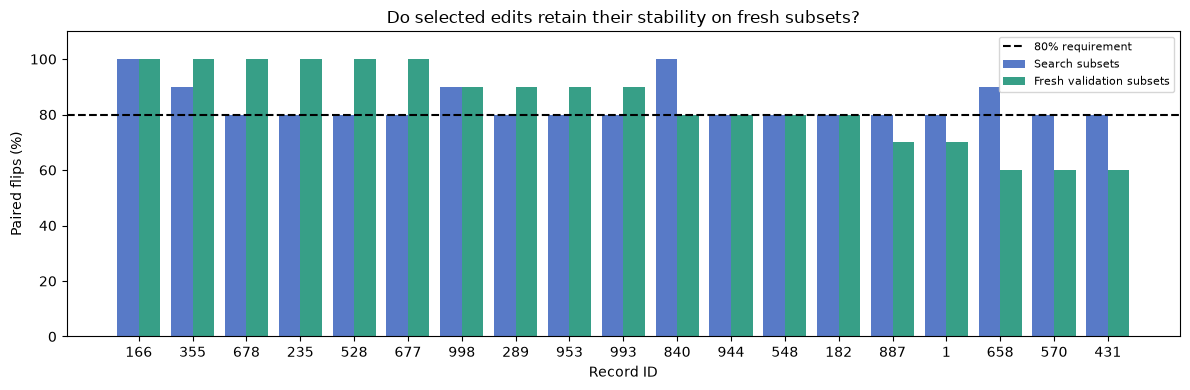

In [12]:
plot_data = validation_report.sort_values(["validation_flip_rate", "search_flip_rate"], ascending=False)
positions = np.arange(len(plot_data))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(positions - 0.2, plot_data.search_flip_rate * 100, width=0.4, label="Search subsets", color="#587ac7")
ax.bar(positions + 0.2, plot_data.validation_flip_rate * 100, width=0.4, label="Fresh validation subsets", color="#379f87")
ax.axhline(80, color="black", linestyle="--", label="80% requirement")
ax.set(xticks=positions, xticklabels=plot_data.index.astype(str), ylim=(0, 110),
       xlabel="Record ID", ylabel="Paired flips (%)", title="Do selected edits retain their stability on fresh subsets?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
import json

evidence = {
    "metadata": {
        "dataset": "OpenML credit-g version 1", "threshold": THRESHOLD,
        "search_repeats": SEARCH_REPEATS, "validation_repeats": VALIDATION_REPEATS,
        "model_selection": "automatic_default", "client_version": config["client_version"],
        "cost": "relative reduction among tested single-feature edits",
        "scope": "cached experiment; validation uses fresh subsets of the same training pool"
    },
    "records": [{"record_id": int(rid), "original_probability": float(baseline.at[rid, "p_bad"])}
                for rid in original_ids],
    "candidates": json.loads(stable_candidates.reset_index().to_json(orient="records")),
    "validation": json.loads(validation_report.rename_axis("record_id").reset_index().to_json(orient="records"))
}
EVIDENCE_PATH = RUN_DIR / "decision_probe_evidence.json"
EVIDENCE_PATH.write_text(json.dumps(evidence, indent=2, allow_nan=False), encoding="utf-8")
print("Evidence exported:", EVIDENCE_PATH.resolve())

Evidence exported: /homes/mxqasim/Hackathon/decision_probe_results/stable_search_412b57d59795/decision_probe_evidence.json


In [14]:
import math

records_lookup = {row["record_id"]: row for row in evidence["records"]}

def attach_validation(candidate):
    result = dict(candidate)
    matches = [
        row for row in evidence["validation"]
        if row["record_id"] == candidate["record_id"] and row["feature"] == candidate["feature"]
        and math.isclose(row["new_value"], candidate["new_value"], abs_tol=1e-8)
    ]
    result["validation"] = (
        {"status": "tested", **matches[0]} if matches
        else {"status": "not_tested", "reason": "This exact edit was not included in the frozen validation set."}
    )
    return result

def list_records() -> dict:
    """List cached high-risk records available for decision inspection."""
    return {"metadata": evidence["metadata"], "records": evidence["records"]}

def find_edits(record_id: int, minimum_stability: float = 0.8,
               maximum_reduction: float = 1.0, feature: str = "either",
               require_margin: bool = False, limit: int = 5) -> dict:
    """Find smallest cached edits satisfying search stability and change-size constraints.
    Rates are fractions from 0 to 1. Validation is separate evidence, not a selection filter.
    """
    if record_id not in records_lookup:
        raise ValueError("Unknown record_id. Use list_records().")
    if not math.isfinite(minimum_stability) or not 0 < minimum_stability <= 1:
        raise ValueError("minimum_stability must be in (0, 1].")
    if not math.isfinite(maximum_reduction) or not 0 < maximum_reduction <= 1:
        raise ValueError("maximum_reduction must be in (0, 1].")
    if feature not in ("either", "credit_amount", "duration"):
        raise ValueError("feature must be either, credit_amount, or duration.")
    if not 1 <= limit <= 20:
        raise ValueError("limit must be between 1 and 20.")
    metric = "margin_flip_rate" if require_margin else "paired_flip_rate"
    eligible = [
        row for row in evidence["candidates"]
        if row["record_id"] == record_id and row[metric] >= minimum_stability
        and row["relative_reduction"] <= maximum_reduction + 1e-9
        and (feature == "either" or row["feature"] == feature)
    ]
    eligible.sort(key=lambda row: (
        row["relative_reduction"], -row[metric], row["mean_modified_p"], row["feature"]
    ))
    return {
        "status": "found" if eligible else "no_qualifying_tested_edit",
        "record": records_lookup[record_id],
        "constraints": {"minimum_search_stability": minimum_stability,
                        "maximum_reduction": maximum_reduction, "feature": feature,
                        "require_margin": require_margin},
        "qualifying_count": len(eligible),
        "edits": [attach_validation(row) for row in eligible[:limit]],
        "interpretation": "Search-selected hypothetical edits; no causal or future-outcome guarantee."
    }

def inspect_edit(candidate_id: int) -> dict:
    """Return search and exact-edit validation evidence for a cached candidate."""
    matches = [row for row in evidence["candidates"] if row["candidate_id"] == candidate_id]
    if not matches:
        raise ValueError("Unknown candidate_id.")
    return attach_validation(matches[0])

In [15]:
result = find_edits(431, minimum_stability=0.8, maximum_reduction=0.5)
assert result["status"] == "found"
selected = result["edits"][0]
assert selected["validation"]["status"] == "tested"
assert selected["validation"]["validation_flip_rate"] < 0.8
assert find_edits(431, minimum_stability=0.8, maximum_reduction=0.4)["status"] == "no_qualifying_tested_edit"

print(json.dumps(result, indent=2))
print("\nChecks passed: constrained search, separate validation evidence, and no-result handling.")

{
  "status": "found",
  "record": {
    "record_id": 431,
    "original_probability": 0.6460965871810913
  },
  "constraints": {
    "minimum_search_stability": 0.8,
    "maximum_reduction": 0.5,
    "feature": "either",
    "require_margin": false
  },
  "qualifying_count": 2,
  "edits": [
    {
      "candidate_id": 502,
      "record_id": 431,
      "feature": "credit_amount",
      "old_value": 11328.0,
      "new_value": 6230.0,
      "relative_reduction": 0.4500353107,
      "original_high_risk_rate": 1.0,
      "modified_low_risk_rate": 0.8,
      "paired_flip_rate": 0.8,
      "margin_flip_rate": 0.6,
      "mean_original_p": 0.5940893292,
      "mean_modified_p": 0.4690996796,
      "mean_delta_p": -0.1249896497,
      "validation": {
        "status": "tested",
        "record_id": 431,
        "feature": "credit_amount",
        "old_value": 11328.0,
        "new_value": 6230.0,
        "relative_reduction": 0.4500353107,
        "search_flip_rate": 0.8,
        "validation

In [16]:
%pip install -q -U mcp


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
from mcp.server import MCPServer

mcp_server = MCPServer("TabPFN Decision Probe")
mcp_server.tool()(list_records)
mcp_server.tool()(find_edits)
mcp_server.tool()(inspect_edit)
print("Registered MCP tools: list_records, find_edits, inspect_edit")

Registered MCP tools: list_records, find_edits, inspect_edit


In [22]:
from mcp import Client
import json

def extract_mcp_data(result):
    if result.is_error:
        raise RuntimeError(str(result.content))
    if result.structured_content is not None:
        return result.structured_content
    for block in result.content:
        text = getattr(block, "text", None)
        if text:
            try:
                return json.loads(text)
            except json.JSONDecodeError:
                continue
    raise ValueError(f"No JSON data found: {result.content}")

async with Client(MCP_URL) as client:
    records_data = extract_mcp_data(await client.call_tool("list_records", {}))
    search_data = extract_mcp_data(await client.call_tool("find_edits", {
        "record_id": 431, "minimum_stability": 0.8, "maximum_reduction": 0.5, "limit": 2
    }))
    blocked_data = extract_mcp_data(await client.call_tool("find_edits", {
        "record_id": 431, "minimum_stability": 0.8, "maximum_reduction": 0.4
    }))
    inspected_data = extract_mcp_data(await client.call_tool("inspect_edit", {"candidate_id": 502}))

assert search_data["status"] == "found"
assert blocked_data["status"] == "no_qualifying_tested_edit"
assert inspected_data["candidate_id"] == 502
assert abs(search_data["edits"][0]["validation"]["validation_flip_rate"] - 0.6) < 1e-8

transcript = {
    "transport": "streamable-http",
    "request": {"tool": "find_edits", "arguments": {
        "record_id": 431, "minimum_stability": 0.8, "maximum_reduction": 0.5, "limit": 2
    }},
    "response": search_data, "constrained_response": blocked_data
}
(RUN_DIR / "mcp_demo_transcript.json").write_text(
    json.dumps(transcript, indent=2, allow_nan=False), encoding="utf-8"
)
print("MCP checks passed and transcript saved.")

INFO:     127.0.0.1:35800 - "POST /mcp HTTP/1.1" 200 OK


[10/05/26 20:52:53] INFO     HTTP Request: POST http://127.0.0.1:8765/mcp "HTTP/1.1 200 OK"         ]8;id=15875407;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py\_client.py]8;;\:]8;id=15875408;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py#1923\1923]8;;\

INFO:     127.0.0.1:35800 - "POST /mcp HTTP/1.1" 200 OK


                    INFO     HTTP Request: POST http://127.0.0.1:8765/mcp "HTTP/1.1 200 OK"         ]8;id=15875413;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py\_client.py]8;;\:]8;id=15875414;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py#1923\1923]8;;\

INFO:     127.0.0.1:35800 - "POST /mcp HTTP/1.1" 200 OK


...

INFO:     127.0.0.1:35800 - "POST /mcp HTTP/1.1" 200 OK


                    INFO     HTTP Request: POST http://127.0.0.1:8765/mcp "HTTP/1.1 200 OK"         ]8;id=15875431;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py\_client.py]8;;\:]8;id=15875432;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py#1923\1923]8;;\

INFO:     127.0.0.1:35800 - "POST /mcp HTTP/1.1" 200 OK


                    INFO     HTTP Request: POST http://127.0.0.1:8765/mcp "HTTP/1.1 200 OK"         ]8;id=15875437;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py\_client.py]8;;\:]8;id=15875438;file:///homes/mxqasim/gemma4_env/lib/python3.12/site-packages/httpx2/_client.py#1923\1923]8;;\

MCP checks passed and transcript saved.


In [23]:
validation_output = widgets.Output()

def show_validation(change=None):
    with validation_output:
        clear_output(wait=True)
        response = find_edits(
            record_id=record_control.value,
            minimum_stability=stability_control.value / SEARCH_REPEATS,
            maximum_reduction=cost_control.value / 100,
            feature="either" if feature_control.value == "Either" else feature_control.value,
            require_margin=margin_control.value,
            limit=1
        )
        display(HTML("<h3>Fresh-subset validation evidence</h3>"))
        if not response["edits"]:
            print("No edit meets the current search constraints.")
            return

        edit = response["edits"][0]
        validation = edit["validation"]
        print(f"Selected edit: {edit['feature']} {edit['old_value']:g} → {edit['new_value']:g}")
        if validation["status"] == "not_tested":
            print("NOT TESTED: this exact edit has no fresh-subset validation.")
            return

        rate = validation["validation_flip_rate"]
        required = stability_control.value / SEARCH_REPEATS
        status = "MET REQUIREMENT" if rate >= required else "BELOW REQUIREMENT"
        color = "#23856b" if rate >= required else "#b64b3b"
        display(HTML(f"<p style='color:{color};font-weight:bold'>{status} — paired flips on fresh subsets</p>"))
        comparison = pd.DataFrame({
            "Measure": ["Paired flip rate during search", "Paired flip rate during validation",
                        "Original remained high risk during validation",
                        "Modified became low risk during validation"],
            "Observed rate": [edit["paired_flip_rate"], rate,
                              validation["validation_original_high_rate"],
                              validation["validation_modified_low_rate"]]
        })
        comparison["Observed rate"] = comparison["Observed rate"].map(lambda value: f"{value:.0%}")
        display(comparison)
        if margin_control.value:
            print("Validation above checks threshold crossings only; the margin requirement was not validated here.")
        print("Fresh subsets come from the same training pool. These rates are not future-outcome guarantees.")

for control in [record_control, stability_control, cost_control, feature_control, margin_control]:
    control.observe(show_validation, names="value")

display(validation_output)
show_validation()

Output()